# Experiment 5: Decision Tree and Random Forest
## A Comparative Classification Study
### Objectives
- To implement a Decision Tree classifier.
- To extend the Decision Tree into a Random Forest ensemble model.
- To study the impact of hyperparameters on overfitting and generalization.
- To select optimal hyperparameters using 5-Fold Cross-Validation.
- To compare single-tree and ensemble-tree models.


## Theory
### Decision Tree Classifier
A Decision Tree is a supervised learning model that recursively partitions the feature space using impurity measures to form decision rules. At each node, the feature and threshold that maximize the information gain (or minimize impurity) are selected to split the data.

#### Impurity Measures:
- **Entropy**: A measure of disorder or uncertainty in the class distribution:
$$H(D) = -\sum_{i=1}^{C} p_i \log_2 p_i$$
- **Gini Impurity**: A measure of how often a randomly chosen element from the set would be incorrectly labeled:
$$Gini(D) = 1 - \sum_{i=1}^{C} p_i^2$$

where $p_i$ is the probability of class $i$ in dataset $D$.

**Limitation**: Deep decision trees can learn highly complex decision boundaries, making them prone to overfitting (high variance).

### Random Forest Classifier
Random Forest is an ensemble learning technique that trains multiple decision trees in parallel and combines their predictions. It addresses the high variance limitation of individual decision trees through two key mechanisms:
1. **Bootstrap Aggregation (Bagging)**: Each tree is trained on a random bootstrap sample (sampled with replacement) from the training set.
2. **Random Feature Selection**: At each node split, only a random subset of features is considered, which decorrelates the trees.

Predictions are combined using majority voting for classification.

**Advantage**: Reduces variance significantly without a corresponding increase in bias, leading to improved generalization.


## Implementation
### 1. Ingestion & Preprocessing
First, we import the required libraries, load the breast cancer dataset, map class labels to binary target format, and perform Exploratory Data Analysis.


In [20]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)

# Set random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Path to the dataset
data_path = 'wdbc.data'

# Column names for WDBC dataset
feature_names = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
col_names = ['id', 'diagnosis'] + feature_names

# Load data
df = pd.read_csv(data_path, header=None, names=col_names)
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Exploratory Data Analysis (EDA)
We map the diagnosis label `M` (Malignant) to `1` and `B` (Benign) to `0`, and check the class distribution and correlations.


Class distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64
Malignant percentage: 37.26%
Benign percentage: 62.74%


C:\Users\priya\AppData\Local\Temp\ipykernel_10804\418518225.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='Set2')


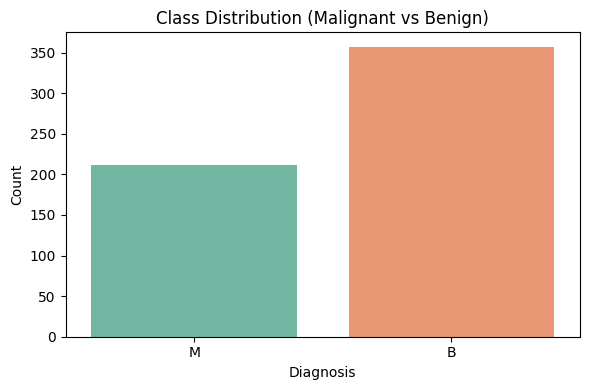

In [21]:
# Target Mapping
df['target'] = df['diagnosis'].map({'B': 0, 'M': 1})

# Class distribution
counts = df['diagnosis'].value_counts()
print('Class distribution:')
print(counts)
print('Malignant percentage:', f'{counts["M"]/len(df)*100:.2f}%')
print('Benign percentage:', f'{counts["B"]/len(df)*100:.2f}%')

# Create figures folder if not exists
os.makedirs('figures', exist_ok=True)

# Class Distribution Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, palette='Set2')
plt.title('Class Distribution (Malignant vs Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=300)
plt.show()


#### Correlation Analysis
We evaluate the correlation of all features with the target variable to see which characteristics are most predictive of malignancy.


Top 10 correlated features with Target:
target                  1.000000
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: target, dtype: float64


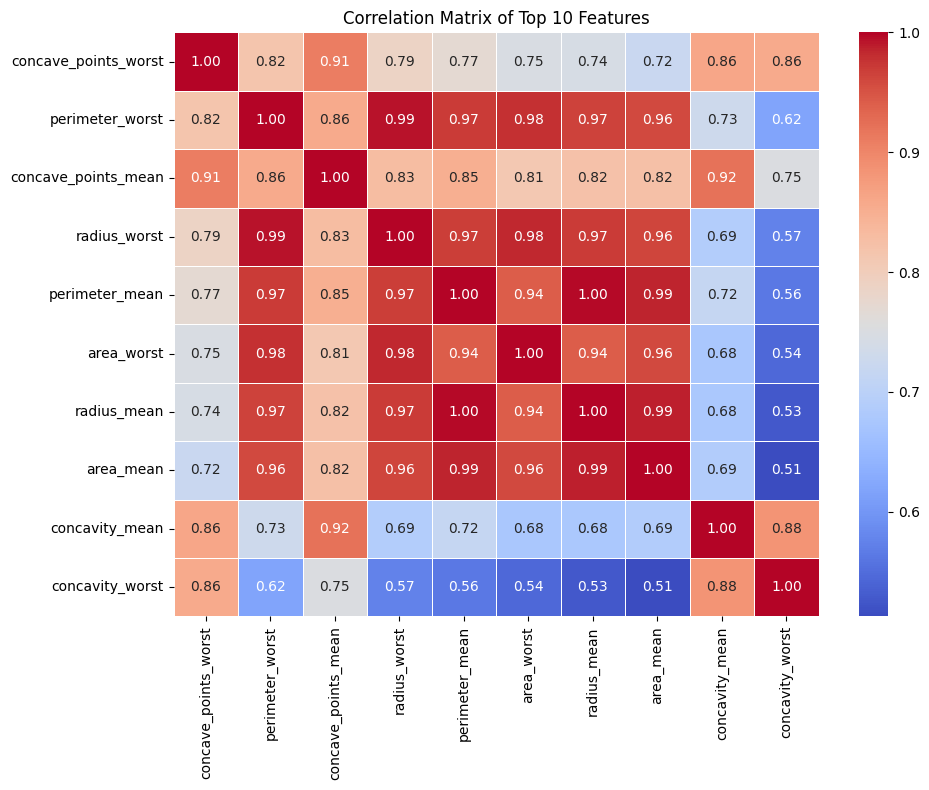

In [22]:
correlations = df.drop(columns=['id', 'diagnosis']).corr()['target'].sort_values(ascending=False)
print('Top 10 correlated features with Target:')
print(correlations.head(11))

# Correlation Heatmap for Top 10 correlated features
top_corr_features = correlations.abs().sort_values(ascending=False).index[1:11]
plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Top 10 Features')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=300)
plt.show()


### 3. Train-Test Split
We split the data into an 80% training set and a 20% test set, ensuring stratified sampling to maintain class proportions.


In [23]:
X = df[feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Training features shape: {X_train.shape}')
print(f'Testing features shape: {X_test.shape}')
print(f'Training class balance:\n{y_train.value_counts(normalize=True)}')
print(f'Testing class balance:\n{y_test.value_counts(normalize=True)}')


Training features shape: (455, 30)
Testing features shape: (114, 30)
Training class balance:
target
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Testing class balance:
target
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 4. Decision Tree Classifier & Hyperparameter Tuning
We define a grid search over the Decision Tree hyperparameter space and use 5-Fold Stratified Cross-Validation on the training set to identify the optimal configuration.


In [24]:
dt_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_search = GridSearchCV(
    dt_clf, dt_grid, cv=skf, scoring=['accuracy', 'f1'], refit='accuracy', return_train_score=True, n_jobs=-1
)
dt_search.fit(X_train, y_train)

print('Best Decision Tree Hyperparameters:', dt_search.best_params_)
print(f'Best CV Accuracy: {dt_search.best_score_*100:.2f}%')


Best Decision Tree Hyperparameters: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Accuracy: 94.07%


#### Decision Tree Hyperparameter Tuning Results (Table 1)
Below we show the 5-fold cross-validation performance of representative hyperparameter combinations (varying `criterion` and `max_depth` with default splits and leaves).


In [25]:
dt_results_df = pd.DataFrame(dt_search.cv_results_)
table1_rows = dt_results_df[
    (dt_results_df['param_min_samples_split'] == 2) & 
    (dt_results_df['param_min_samples_leaf'] == 1)
][['param_criterion', 'param_max_depth', 'mean_test_accuracy', 'mean_test_f1']].copy()

table1_rows['mean_test_accuracy'] = table1_rows['mean_test_accuracy'] * 100
table1_rows.rename(columns={
    'param_criterion': 'Criterion',
    'param_max_depth': 'Max Depth',
    'mean_test_accuracy': 'Avg CV Accuracy (%)',
    'mean_test_f1': 'Avg CV F1 Score'
}, inplace=True)
print(table1_rows.to_string(index=False))


Criterion Max Depth  Avg CV Accuracy (%)  Avg CV F1 Score
     gini         3            92.087912         0.888437
     gini         4            92.087912         0.889710
     gini         5            90.769231         0.871738
     gini         6            92.087912         0.891928
     gini         8            92.307692         0.896184
     gini        10            92.307692         0.896184
     gini      None            92.307692         0.896184
  entropy         3            92.527473         0.894103
  entropy         4            93.846154         0.914479
  entropy         5            92.307692         0.895159
  entropy         6            91.648352         0.887519
  entropy         8            91.868132         0.890865
  entropy        10            91.868132         0.890865
  entropy      None            91.868132         0.890865


### 5. Random Forest Classifier & Hyperparameter Tuning
We repeat the hyperparameter selection process for the Random Forest ensemble model.


In [26]:
rf_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_clf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_search = GridSearchCV(
    rf_clf, rf_grid, cv=skf, scoring=['accuracy', 'f1'], refit='accuracy', return_train_score=True, n_jobs=-1
)
rf_search.fit(X_train, y_train)

print('Best Random Forest Hyperparameters:', rf_search.best_params_)
print(f'Best CV Accuracy: {rf_search.best_score_*100:.2f}%')


Best Random Forest Hyperparameters: {'bootstrap': False, 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV Accuracy: 97.14%


#### Random Forest Hyperparameter Tuning Results (Table 2)
Below we show the 5-fold cross-validation performance of representative hyperparameter combinations (varying `n_estimators`, `max_depth` with `max_features='sqrt'` and `bootstrap=True`).


In [27]:
rf_results_df = pd.DataFrame(rf_search.cv_results_)
table2_rows = rf_results_df[
    (rf_results_df['param_max_features'] == 'sqrt') & 
    (rf_results_df['param_bootstrap'] == True)
][['param_n_estimators', 'param_max_depth', 'param_max_features', 'mean_test_accuracy', 'mean_test_f1']].copy()

table2_rows['mean_test_accuracy'] = table2_rows['mean_test_accuracy'] * 100
table2_rows.rename(columns={
    'param_n_estimators': 'n estimators',
    'param_max_depth': 'Max Depth',
    'param_max_features': 'Max Features',
    'mean_test_accuracy': 'Avg CV Accuracy (%)',
    'mean_test_f1': 'Avg CV F1 Score'
}, inplace=True)
print(table2_rows.to_string(index=False))


 n estimators Max Depth Max Features  Avg CV Accuracy (%)  Avg CV F1 Score
           50         3         sqrt            95.824176         0.943160
          100         3         sqrt            95.604396         0.940087
          200         3         sqrt            95.604396         0.940087
           50         5         sqrt            96.263736         0.949046
          100         5         sqrt            96.703297         0.955285
          200         5         sqrt            95.604396         0.940087
           50        10         sqrt            96.043956         0.946423
          100        10         sqrt            96.483516         0.951945
          200        10         sqrt            96.043956         0.946148
           50      None         sqrt            96.043956         0.946423
          100      None         sqrt            96.483516         0.951945
          200      None         sqrt            96.263736         0.948876


### 6. Model Comparison using 5-Fold Cross-Validation (Table 3)
We evaluate the fold-by-fold accuracy for both optimized models to study consistency and variance.


In [28]:
best_dt = DecisionTreeClassifier(**dt_search.best_params_, random_state=RANDOM_STATE)
best_rf = RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_STATE)

dt_cv = cross_validate(best_dt, X_train, y_train, cv=skf, scoring='accuracy')
rf_cv = cross_validate(best_rf, X_train, y_train, cv=skf, scoring='accuracy')

dt_folds = dt_cv['test_score']
rf_folds = rf_cv['test_score']

comparison_data = {
    'Model': ['Decision Tree', 'Random Forest'],
    'Fold 1': [dt_folds[0], rf_folds[0]],
    'Fold 2': [dt_folds[1], rf_folds[1]],
    'Fold 3': [dt_folds[2], rf_folds[2]],
    'Fold 4': [dt_folds[3], rf_folds[3]],
    'Fold 5': [dt_folds[4], rf_folds[4]],
    'Average': [dt_folds.mean(), rf_folds.mean()]
}

comparison_df = pd.DataFrame(comparison_data)
for col in ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Average']:
    comparison_df[col] = comparison_df[col] * 100

print(comparison_df.to_string(index=False))


        Model    Fold 1     Fold 2    Fold 3    Fold 4    Fold 5   Average
Decision Tree 93.406593  95.604396 90.109890 95.604396 95.604396 94.065934
Random Forest 95.604396 100.000000 94.505495 96.703297 98.901099 97.142857


### 7. Evaluation on the Test Set
We train both optimal models on the full training set and evaluate them on the 20% independent test set.


In [29]:
# Fit on entire train data
best_dt.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

# Predictions
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Metrics computation
dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-score': f1_score(y_test, y_pred_dt),
    'ROC-AUC': roc_auc_score(y_test, y_prob_dt)
}

rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

eval_df = pd.DataFrame([dt_metrics, rf_metrics], index=['Decision Tree', 'Random Forest'])
print(eval_df)


               Accuracy  Precision    Recall  F1-score   ROC-AUC
Decision Tree  0.929825        1.0  0.809524  0.894737  0.956349
Random Forest  0.964912        1.0  0.904762  0.950000  0.993717


### 8. Result Visualizations
We plot and save the evaluation visualizations, including confusion matrices and ROC curves.


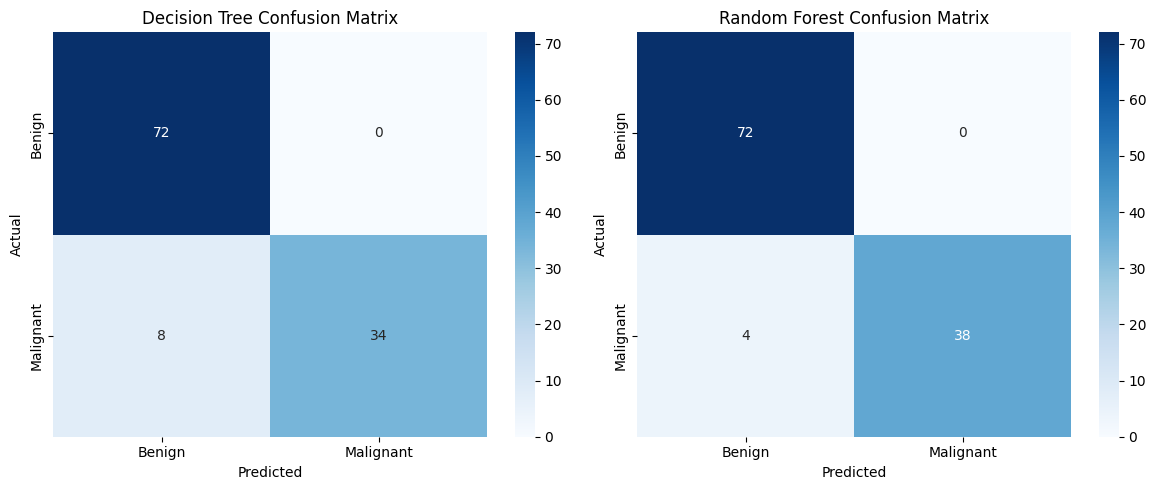

In [30]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Confusion Matrices Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[0].set_title('Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[1].set_title('Random Forest Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig('figures/confusion_matrices.png', dpi=300)
plt.show()


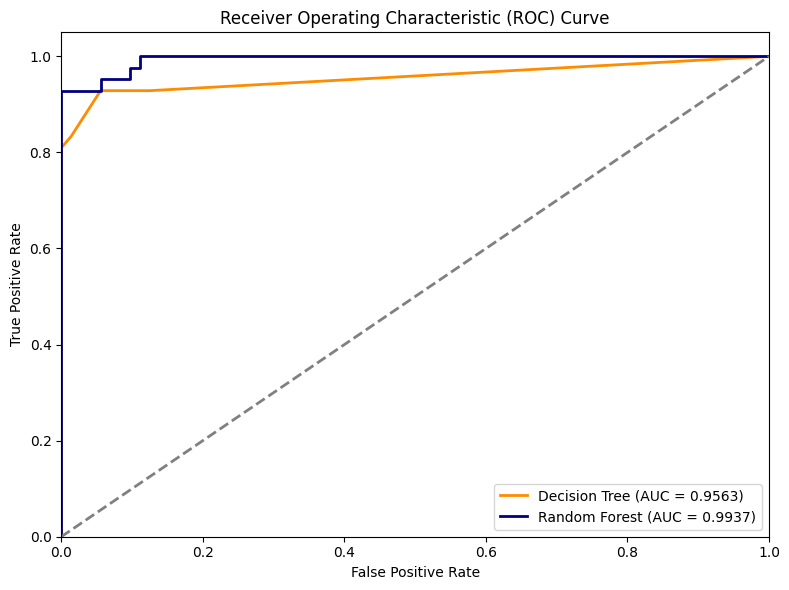

In [31]:
# ROC Curves Plot
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc(fpr_dt, tpr_dt):.4f})', color='darkorange', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})', color='navy', lw=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=300)
plt.show()


#### Tree Structure and Feature Importance Analysis
We visualize the structure of the optimized Decision Tree and plot the relative importances of features from the Random Forest model.


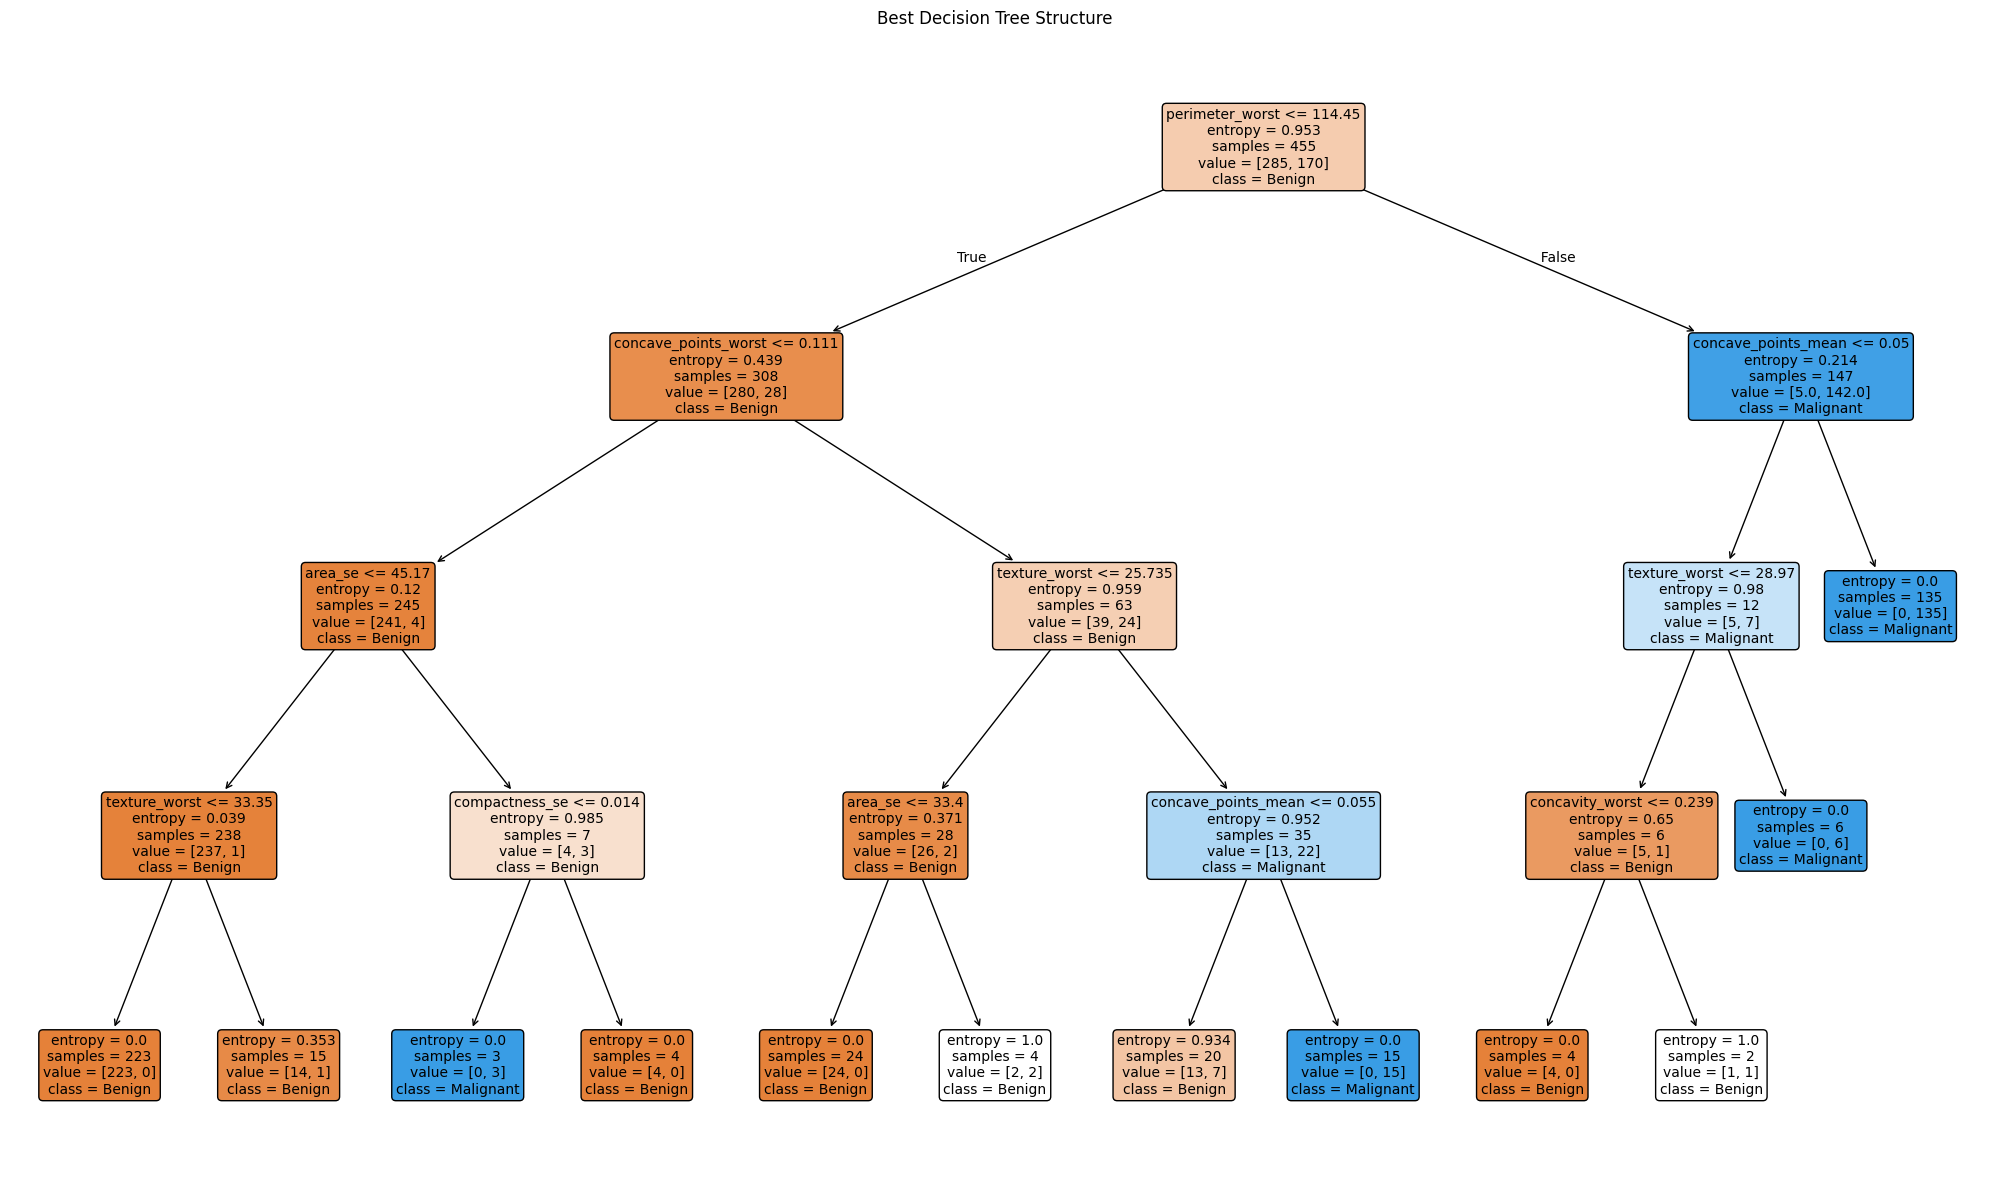

In [32]:
# Plot Decision Tree Structure
plt.figure(figsize=(20, 12))
plot_tree(best_dt, feature_names=feature_names, class_names=['Benign', 'Malignant'], filled=True, rounded=True, fontsize=10)
plt.title('Best Decision Tree Structure')
plt.tight_layout()
plt.savefig('figures/decision_tree_structure.png', dpi=300)
plt.show()


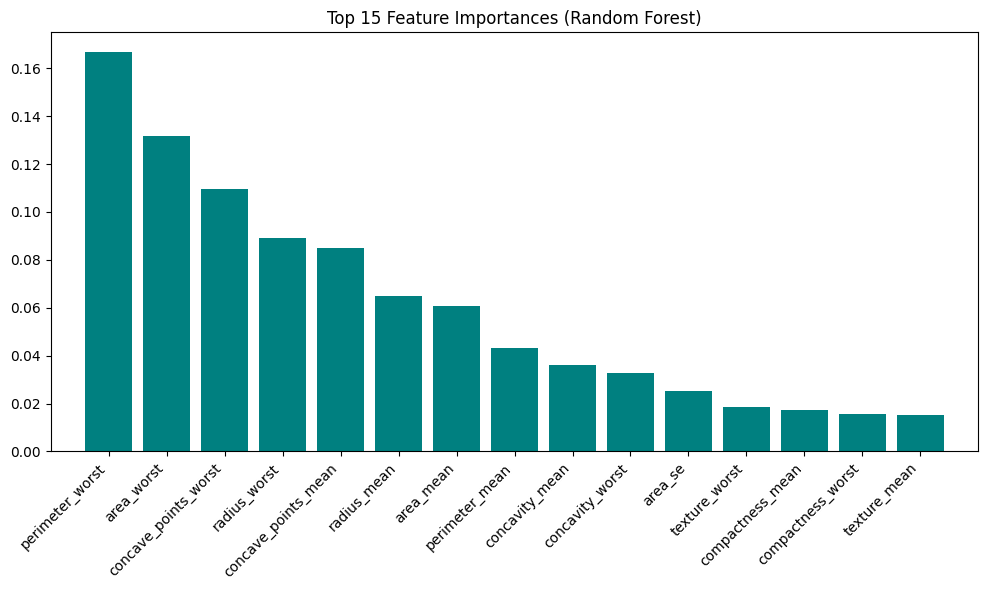

In [14]:
# Plot Feature Importances
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10, 6))
plt.title(f'Top {top_n} Feature Importances (Random Forest)')
plt.bar(range(top_n), importances[indices[:top_n]], align='center', color='teal')
plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.xlim([-1, top_n])
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=300)
plt.show()
